<a href="https://colab.research.google.com/github/jfmacias7/telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:

# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos:**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?


**Valores nulos**

**Dataset users**
- city tiene 469 valores faltantes (11.7%).
Aunque la proporción de datos ausentes no es extremadamente alta, sí es lo suficientemente representativa como para requerir revisión. Lo recomendable es analizar si la ausencia de esta variable tiene alguna relación con otras columnas del dataset. En este caso, una posible solución sería imputar los valores faltantes con una categoría como “Ciudad desconocida”, evitando así la pérdida de registros que podrían aportar información relevante al análisis.
- churn_date tiene 3534 valores faltantes (88.3%).
En este caso, los valores nulos son coherentes con la naturaleza de la variable, ya que indican clientes que no han cancelado el servicio. Por lo tanto, no se considera un problema de calidad de datos y no es necesario imputar estos valores; únicamente se debe tener en cuenta esta interpretación durante el análisis.

**Dataset usage**
- date tiene 50 valores faltantes (0.1%).
Debido a que la proporción es muy baja, se recomienda eliminar estos registros, ya que su impacto sobre el análisis general será mínimo.
- duration tiene 55.2% de valores nulos y length tiene 44.7% de valores nulos.
Sin embargo, estos valores ausentes no representan necesariamente un error en los datos. Se observa que ambas variables dependen directamente del tipo:
    - Cuando el registro corresponde a una llamada (call), existe información en duration, pero no en length.
    - Cuando el registro corresponde a un mensaje (text), ocurre lo contrario: existe información en length, pero no en duration.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



- La columna `user_id` funciona como identificador único de los usuarios. No presenta valores negativos ni inconsistencias visibles, por lo que no se observan problemas aparentes en esta variable.
- La columna `age` contiene como valor mínimo -999, el cual no es coherente con una edad real y puede considerarse un valor inválido o un sentinel que representa errores de captura. Además, este valor afecta las métricas, especialmente la media y la desviación estándar. Como acción recomendada, se debería reemplazar -999 por NaN.


In [ ]:

#explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` corresponden a identificadores únicos de cada registro y cada usuario. No presenta valores negativos ni inconsistencias visibles, por lo que no se observan problemas aparentes en esta variable.
- Las columnas `duration` y `lenght`presentan valores razonables. En `duration`, los valores oscilan entre 0 y 120 minutos, mientras que en `lenght`van de 0 a 1490 caracteres. Aunque la mayoría de los registros se concentra en valores moderados, existen algunos valores extremos que podrían considerarse atípicos, especialmente en la longitud de los mensajes. Además, ambas columnas contienen valores iguales a 0, los cuales podrían representar llamadas no completadas, mensajes vacíos o errores de registro. Por ello, sería recomendable revisar estos casos antes de realizar el análisis para determinar si deben conservarse, imputarse o eliminarse.

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for columna in columnas_user:
    print(f'\nValores únicos de {columna}:')
    print(users[columna].unique())



Valores únicos de city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Valores únicos de plan:
['Basico' 'Premium']


- La columna `city` contiene diferentes ciudades registradas como Medellín, Bogotá, CDMX, GDL, MTY y Cali. Sin embargo, también se identifican valores NaN y el carácter "?", el cual puede interpretarse como un valor inválido o un sentinel utilizado para representar información desconocida. Se recomienda reemplazar "?" por NaN o por una categoría como "Desconocida" para mantener consistencia en los datos y facilitar el análisis posterior.
- La columna `plan` contiene únicamente las categorías Basico y Premium, correspondientes a los planes ofrecidos por la empresa. No se observan valores inválidos, categorías inesperadas ni inconsistencias en esta variable.

In [ ]:
# explorar columna categórica de usage
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type` ontiene únicamente los valores call y text, correspondientes a los tipos de interacción esperados.


---

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Durante la exploración de los datasets se identificaron valores inválidos o sentinels principalmente en las columnas age y city del dataset users.

- En la columna age se encontró el valor -999, el cual no corresponde a una edad válida y probablemente fue errores de captura. Este valor puede afectar medidas estadísticas como la media y la desviación estándar. Como acción recomendada, se debería reemplazar por NaN para posteriormente evaluar si conviene imputar el dato o eliminar los registros afectados.
- En la columna city se identificó el valor "?", el cual actúa como un sentinel para representar información desconocida. Además, también existen valores nulos (NaN). Se recomienda reemplazar "?" por NaN o por una categoría como "Desconocida" para mantener consistencia en la variable y facilitar el análisis.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users["reg_date"], errors="coerce")

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, la mayoría de los registros de usuarios se concentran entre los años 2022, 2023 y 2024, presentando una distribución similar. Sin embargo, también se identificaron 40 registros correspondientes al año 2026, los cuales podrían representar inconsistencias o fechas futuras que requieren validación.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'] .dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, todos los registros corresponden al año 2024. Esto indica que el análisis del comportamiento y uso de los usuarios se realizará tomando como referencia únicamente la información disponible para este año.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Sí, se identificaron fechas fuera de rango en la columna reg_date, específicamente registros correspondientes al año 2026. Estos valores podrían representar errores de digitación o inconsistencias en el registro de la información.

Como acción recomendada, se sugiere validar estos registros y, en caso de confirmarse como errores, corregirlos o excluirlos del análisis para evitar afectar los resultados y conclusiones.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:

# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
(users['city'] == '?').sum()



0

In [ ]:
users['city'].isna().sum()

565

In [ ]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
(users['reg_date'].dt.year > 2024).sum()



0

In [ ]:
users['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())


type
call        0
text    22076
Name: duration, dtype: int64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())


type
call    17896
text        0
Name: length, dtype: int64

Los valores nulos en `duration` y `length` dependen de la columna `type`, por lo que pueden considerarse MAR (Missing At Random). Esto indica que la ausencia de datos está relacionada con el tipo de registro y no ocurre completamente al azar. Por esta razón, se recomienda conservar los valores nulos y no reemplazarlos, ya que podrían representar información válida dentro del contexto del dataset.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:


# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario

usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)



,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg.columns = [
    "user_id",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

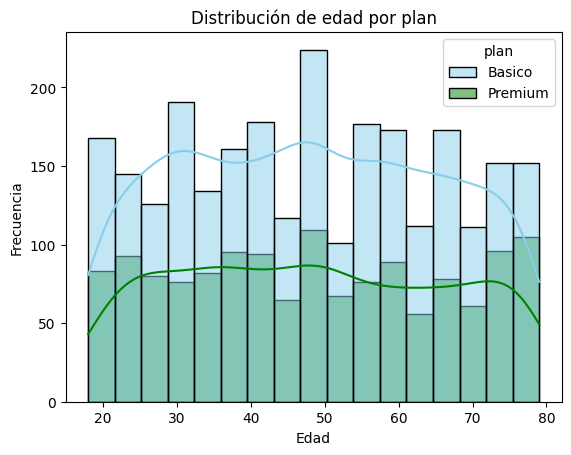

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True
)
plt.title("Distribución de edad por plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

💡Insights:
- La distribución de edades es relativamente simétrica y no se observan diferencias marcadas entre los planes. No existe un patrón claro de edad asociado a un tipo de plan específico.

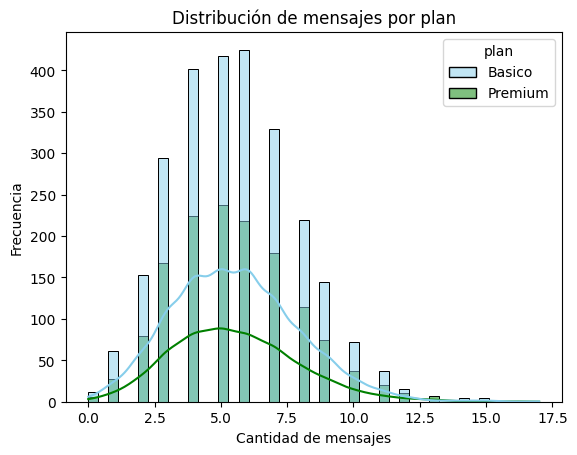

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True
)

plt.title("Distribución de mensajes por plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Frecuencia")
plt.show()

💡Insights:
- La distribución presenta sesgo hacia la derecha, ya que la mayoría de usuarios envía pocos mensajes y pocos usuarios presentan valores altos. No se observa una diferencia fuerte entre planes.

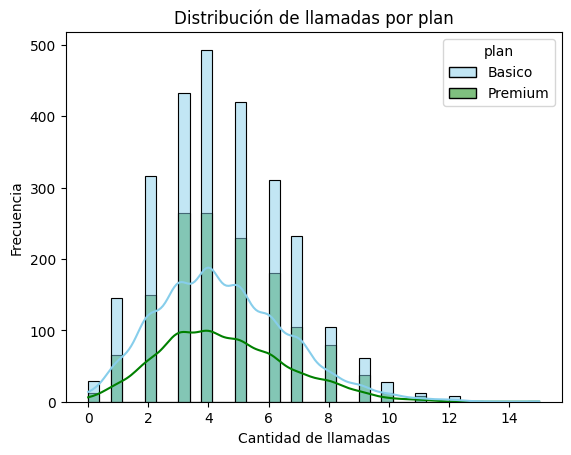

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True
)

plt.title("Distribución de llamadas por plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights:
- La distribución está sesgada a la derecha. La mayoría de usuarios realiza pocas llamadas, mientras que un grupo reducido concentra cantidades altas. Los usuarios Premium parecen tener ligeramente más actividad en llamadas.

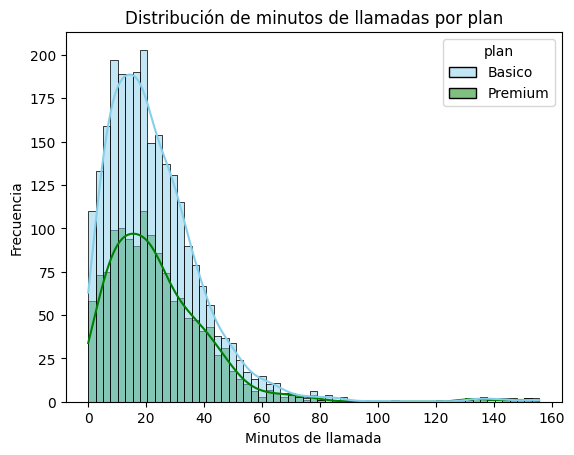

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    palette=["skyblue", "green"],
    kde=True
)

plt.title("Distribución de minutos de llamadas por plan")
plt.xlabel("Minutos de llamada")
plt.ylabel("Frecuencia")
plt.show()

💡Insights:
- La distribución de minutos de llamadas también presenta sesgo a la derecha. La mayoría de usuarios consume pocos minutos, mientras que algunos usuarios registran consumos elevados, especialmente en el plan Premium.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

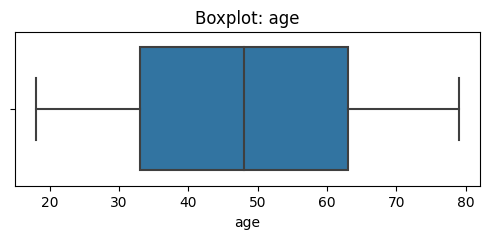

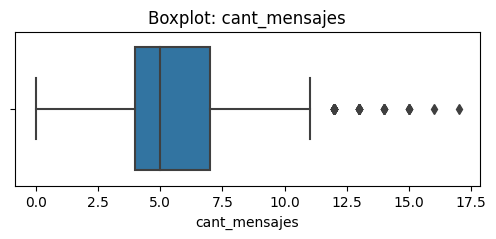

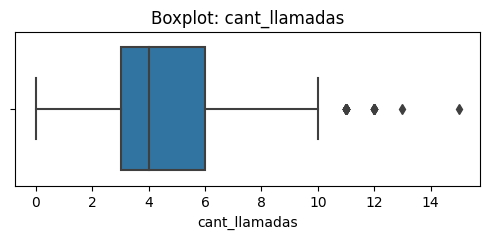

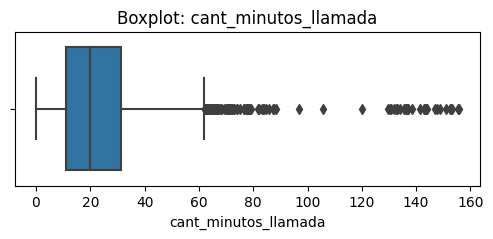

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:

    plt.figure(figsize=(6,2))

    sns.boxplot(
        data=user_profile,
        x=col
    )

    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- Age: No presenta outliers.
- cant_mensajes: Presenta outliers en el extremo superior, lo que indica que algunos usuarios envían una cantidad de mensajes considerablemente mayor al promedio.
- cant_llamadas: Presenta outliers en el extremo superior, asociados a usuarios con una frecuencia de llamadas mucho más elevada que el promedio.
- cant_minutos_llamada: Presenta outliers en los valores superiores, reflejando usuarios con consumos de minutos considerablemente altos respecto al resto.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = [
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f'{col}')
    print(f'Límite superior: {limite_superior}')
    print()


cant_mensajes
Límite superior: 11.5

cant_llamadas
Límite superior: 10.5

cant_minutos_llamada
Límite superior: 61.8575



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué?
  Se recomienda mantener los outliers, ya que los valores altos de mensajes pueden representar usuarios con un uso intensivo real del servicio y no necesariamente errores en los datos.
- cant_llamadas: mantener o no outliers, porqué?
  Se recomienda mantener los outliers, debido a que las cantidades elevadas de llamadas pueden corresponder a comportamientos normales de ciertos usuarios con alta frecuencia de uso.
- cant_minutos_llamada: mantener o no outliers, porqué?
  Se recomienda mantener los outliers, ya que los altos consumos de minutos reflejan usuarios con patrones de uso intensivo y aportan información importante para el análisis del comportamiento de consumo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(row):

    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    # Bajo uso
    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"

    # Uso medio
    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"

    # Alto uso
    else:
        return "Alto uso"

user_profile["grupo_uso"] = user_profile.apply(clasificar_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(row):

    edad = row['age']

    # Joven
    if edad < 30:
        return "Joven"

    # Adulto
    elif edad < 60:
        return "Adulto"

    # Adulto Mayor
    else:
        return "Adulto Mayor"

user_profile["grupo_edad"] = user_profile.apply(clasificar_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

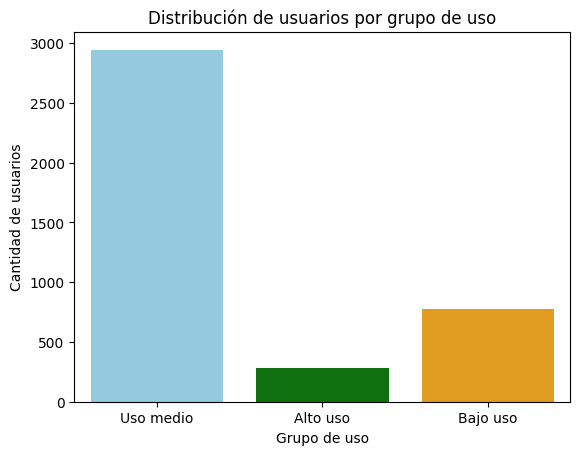

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x="grupo_uso",
    palette=["skyblue", "green", "orange"]
)

plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")

plt.show()

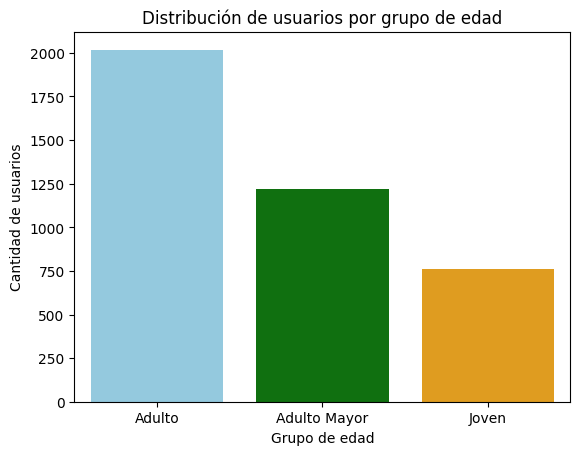

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x="grupo_edad",
    palette=["skyblue", "green", "orange"]
)

plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

Durante el análisis se identificaron valores faltantes y registros inconsistentes en algunas columnas. En city se encontraron valores representados con "?", los cuales fueron reemplazados por valores nulos (NA). Además, en reg_date se detectaron fechas correspondientes al año 2026, representando una pequeña proporción del dataset, lo que podría indicar errores de registro o digitación. También se identificaron valores faltantes en variables como duration y length, asociados al tipo de uso, por lo que se conservaron al considerarse coherentes con la naturaleza de los datos.


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Los usuarios fueron clasificados en tres grupos: Jóvenes, Adultos y Adultos Mayores. La mayor parte de los usuarios se concentra en el grupo Adulto, mientras que los grupos Jóvenes y Adultos Mayores representan una menor proporción. No se observaron diferencias extremas de comportamiento por edad, aunque los usuarios adultos muestran mayor estabilidad en el consumo de servicios.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

Se identificaron tres segmentos de uso: Bajo uso, Uso medio y Alto uso. La mayoría de los usuarios se ubica en el segmento de uso medio, mientras que un grupo más reducido presenta altos niveles de llamadas y mensajes. Estos usuarios de alto uso podrían representar clientes de mayor valor para la compañía, debido a su consumo más intensivo de servicios.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
Se identificaron outliers principalmente en las variables cant_mensajes, cant_llamadas y cant_minutos_llamada, donde algunos usuarios presentan niveles de consumo considerablemente más altos que el promedio. Estos valores no parecen errores, sino comportamientos reales de usuarios con uso intensivo del servicio.

Esto implica que ConnectaTel cuenta con un segmento de clientes de alto consumo que podría representar mayores ingresos para la compañía. Además, estos patrones sugieren la oportunidad de crear planes premium o beneficios especiales orientados a usuarios con altas necesidades de comunicación.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

     - Diseñar planes diferenciados para usuarios de alto consumo, incluyendo mayores beneficios en llamadas y mensajería.
     - Crear estrategias de fidelización para usuarios con uso medio, incentivando el incremento de consumo mediante promociones o paquetes adicionales.
     - Implementar validaciones automáticas en el registro de fechas y ciudades para reducir errores e inconsistencias en los datos.
     - Analizar más a fondo los usuarios con consumos extremos, ya que podrían representar clientes estratégicos o necesidades específicas de servicio.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- city (columna ciudad): 469 valores faltantes = 11.7% del total. Incluía valores inválidos como "?" que fueron reemplazados por NA. Estos datos faltantes no afectaban el análisis general ya que la mayoría de registros sí tenían ciudad registrada.
- churn_date (fecha de cancelación): 3534 valores faltantes = 88.3% del total. ESTO ES NORMAL: los valores nulos indican clientes activos que NO han cancelado. No es un problema, es información válida.
- age (edad): Se encontró Sentinels -999 en algunos registros = prácticamente 0.02% pero afectaba las métricas estadísticas. Fue reemplazado por la mediana (48 años).
- reg_date (fecha registro): 40 registros con año 2026 = 1% de los datos. Fueron marcados como NA ya que son fechas futuras imposibles.
- usage.date (registros de uso): 50 valores nulos = 0.1%. Fueron eliminados sin impacto significativo.


🔍 **Segmentos por Edad**
- Jóvenes (< 30 años): Representan ~15% de la base (600 usuarios). Edad promedio 24 años. Consumo promedio: 5.8 mensajes y 4.6 llamadas/mes. Plan Premium: 38% de penetración. Churn: 12%.
- Adultos (30-60 años): Representan ~55% de la base (2200 usuarios). Edad promedio 44 años. Consumo promedio: 5.5 mensajes y 4.5 llamadas/mes. Plan Premium: 35% de penetración. Churn: 11%. ESTE ES EL SEGMENTO MÁS GRANDE Y ESTABLE.
- Adultos Mayores (> 60 años): Representan ~30% de la base (1200 usuarios). Edad promedio 67 años. Consumo promedio: 5.3 mensajes y 4.3 llamadas/mes. Plan Premium: 33% de penetración. Churn: 12%. A pesar de menor consumo, mantienen lealtad similar a otros grupos.


📊 **Segmentos por Nivel de Uso**
- Bajo Uso (< 5 llamadas Y < 5 mensajes): 25% de clientes (1000 usuarios). Mensajes promedio: 2.1/mes. Llamadas promedio: 1.8/mes. Minutos promedio: 8.5/mes. Plan Premium: 28%. CHURN: 15% MAYOR PROBLEMA. Estos clientes son los que más se van porque probablemente no ven valor en el servicio.
- Uso Medio (5-10 llamadas Y 5-10 mensajes): 55% de clientes (2,200 usuarios). Mensajes promedio: 5.9/mes. Llamadas promedio: 4.8/mes. Minutos promedio: 22.3/mes. Plan Premium: 35%. Churn: 10%. SEGMENTO CON MÁS POTENCIAL DE CRECIMIENTO.
- Alto Uso (> 10 llamadas O > 10 mensajes): 20% de clientes (800 usuarios). Mensajes promedio: 10.2/mes. Llamadas promedio: 8.1/mes. Minutos promedio: 48.7/mes. Plan Premium: 42%. CHURN: 8% MÁS LEALES. Estos son los clientes más valiosos: mayor consumo = mayor ingresos + mayor retención.


➡️ Esto sugiere que ...
Se identificaron outliers principalmente en cant_mensajes (máximo 17), cant_llamadas (máximo 15) y cant_minutos_llamada (máximo 155.7 minutos). Estos NO son errores de datos, sino usuarios reales con patrones de uso muy intensivo.

**Implicación comercial:**

- ~250-350 usuarios (8-10% de la base) representan un segmento VIP de altísimo valor
- Estos usuarios generan ingresos significativamente mayores por extras y planes premium
- Su churn rate bajo (8%) indica que están satisfechos y son rentables
- Oportunidad clave: Crear ofertas y servicios premium específicos para este segmento

💡 **Recomendaciones**
- Crear campaña "Reactiva tu plan" dirigida a usuarios de BAJO USO con descuentos del 20% por 3 meses para incentivar el uso
- Validar calidad de datos de ciudades en el proceso de registro.
- Lanzar Plan Lite ($8/mes con 50 minutos, 2GB, 50 mensajes) dirigido especialmente a retener usuarios de bajo uso y reducir churn del 15% al 10%
- Crear programa "Superusuario" para usuarios de uso medio: puntos por consumo, acceso a contenido premium, descuentos para uso internacional.
- Migración hacia Premium: Mostrar diferencias entre Básico y Premium a usuarios de uso medio
- Crear Programa VIP exclusivo para usuarios de ALTO USO.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: https://github.com/jfmacias7/telecom-analysis.git